# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Dina Salwa Mannatu
- **Email:** dinasalwa2105@gmail.com
- **ID Dicoding:** dina_salwa

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1 (Tren Waktu):** Bagaimana tren total penyewaan sepeda per bulan selama tahun 2011 dibandingkan dengan tahun 2012?
- **Pertanyaan 2 (Pengaruh Lingkungan):** Bagaimana pengaruh kondisi cuaca (weathersit) terhadap rata-rata jumlah penyewaan sepeda harian selama periode tahun 2011 hingga 2012?
- **Pertanyaan 3:** Pada jam berapa penyewaan sepeda mencapai puncaknya dalam sehari di tahun 2012, serta bagaimana perbedaan polanya antara hari kerja (workingday) dan hari libur?

## Import Semua Packages/Library yang Digunakan

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

# Mengatur tampilan visualisasi
sns.set(style="whitegrid")

## Data Wrangling

### Gathering Data

#### Load df ...

In [17]:
# Memuat kedua dataset
day_df = pd.read_csv("day.csv")
hour_df = pd.read_csv("hour.csv")

# Menampilkan 5 data teratas
print(day_df.head())

   instant      dteday  season  yr  mnth  holiday  weekday  workingday  \
0        1  2011-01-01       1   0     1        0        6           0   
1        2  2011-01-02       1   0     1        0        0           0   
2        3  2011-01-03       1   0     1        0        1           1   
3        4  2011-01-04       1   0     1        0        2           1   
4        5  2011-01-05       1   0     1        0        3           1   

   weathersit      temp     atemp       hum  windspeed  casual  registered  \
0           2  0.344167  0.363625  0.805833   0.160446     331         654   
1           2  0.363478  0.353739  0.696087   0.248539     131         670   
2           1  0.196364  0.189405  0.437273   0.248309     120        1229   
3           1  0.200000  0.212122  0.590435   0.160296     108        1454   
4           1  0.226957  0.229270  0.436957   0.186900      82        1518   

    cnt  
0   985  
1   801  
2  1349  
3  1562  
4  1600  


**Insight:** (Opsional)
*   Dataset Harian (day_df): Berhasil memuat data agregasi harian yang mencakup 731 baris (catatan selama 2 tahun) dengan kolom informasi cuaca dan jumlah penyewaan sepeda.  
*   Dataset Per Jam (hour_df): Berhasil memuat data detail per jam yang mencakup 17.379 baris, yang memungkinkan analisis pola penggunaan sepeda berdasarkan waktu spesifik dalam satu hari.  
*   Struktur Data: Kedua dataset memiliki kolom kunci seperti dteday (tanggal), season (musim), weathersit (kondisi cuaca), dan cnt (total penyewaan) yang akan digunakan untuk menjawab pertanyaan bisnis.

### Assessing Data

#### Identifying ... problem

In [18]:
# Memeriksa tipe data dan missing values
print(day_df.info())
print("\nMissing values pada day_df:", day_df.isna().sum().sum())
print("Jumlah duplikasi pada day_df:", day_df.duplicated().sum())

print("\n", hour_df.info())
print("\nMissing values pada hour_df:", hour_df.isna().sum().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB
None

Missing values pada day_df: 0
Jumlah duplikasi pada day_df: 0
<class 'pandas.core.frame

**Steps to Take:**
- Mengubah Tipe Data: Mengonversi kolom dteday dari tipe object menjadi tipe datetime agar analisis tren waktu dapat berjalan dengan benar.  
- Mapping Variabel Kategorikal: Mengubah nilai angka pada kolom season dan weathersit menjadi label teks (seperti 'Spring', 'Summer', 'Clear', dll.) sesuai keterangan di Readme.txt agar visualisasi data lebih mudah dipahami oleh audiens.  
- Pengecekan Konsistensi: Memastikan nilai pada kolom temp, atemp, hum, dan windspeed sudah dalam rentang yang masuk akal (tidak ada nilai negatif yang tidak wajar).

**Insight:** (Opsional)
- Kualitas Data Sangat Baik: Tidak ditemukan missing values (data kosong) pada dataset day_df maupun hour_df, sehingga kita tidak perlu melakukan pengisian data (imputation) atau penghapusan baris.  
- Masalah Tipe Data: Ditemukan bahwa kolom dteday terbaca sebagai object/string. Ini adalah masalah umum yang harus diperbaiki di tahap Cleaning agar kita bisa melakukan ekstraksi bulan atau tahun.  
- Skala Data: Kolom seperti temp, hum, dan windspeed sudah dinormalisasi (nilainya antara 0 sampai 1), sehingga memudahkan dalam proses analisis statistik nantinya.

### Cleaning Data

#### Fixing ... problem

In [19]:
# Mengubah dteday menjadi datetime [cite: 17]
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

# Mengonversi angka menjadi label sesuai keterangan Readme.txt
day_df['season'] = day_df['season'].map({1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'})
day_df['weathersit'] = day_df['weathersit'].map({
    1: 'Clear', 2: 'Misty/Cloudy', 3: 'Light Snow/Rain', 4: 'Severe Weather'
})

**Insight:** (Opsional)
- Integritas Data Terjaga: Proses pembersihan data berhasil dilakukan tanpa mengurangi jumlah baris atau kolom asli, sehingga data tetap utuh untuk dianalisis.  
- Kesiapan Analisis Waktu: Dengan berubahnya tipe data dteday menjadi datetime, kita kini dapat mengekstrak informasi temporal seperti tren bulanan atau tahunan secara akurat.  
- Kemudahan Interpretasi: Kolom season dan weathersit yang kini bertipe string (teks) akan membuat grafik visualisasi nantinya jauh lebih mudah dipahami oleh orang lain karena tidak lagi menggunakan kode angka.  
- Data Siap Olah: Dataset kini telah berada dalam format yang standar dan bersih, siap untuk dilanjutkan ke tahap Eksplorasi Data (EDA) dan Visualisasi.  

## Exploratory Data Analysis (EDA)

### Eksplorasi Data Penyewaan Sepeda Berdasarkan Parameter Waktu dan Cuaca

In [20]:
# 1. Eksplorasi tren bulanan (Pertanyaan 1: 2011 vs 2012)
# Menggunakan pivot table atau groupby
monthly_rentals = day_df.resample(rule='ME', on='dteday').agg({
    "cnt": "sum"
}).reset_index()
print(day_df.groupby(by=["yr", "mnth"]).cnt.sum().reset_index())

# 2. Eksplorasi pengaruh cuaca (Pertanyaan 2: Lingkungan)
# Melakukan agregasi untuk melihat rata-rata penyewaan per kondisi cuaca
weather_rentals = day_df.groupby(by="weathersit").cnt.mean().sort_values(ascending=False).reset_index()
print(weather_rentals)

# 3. Eksplorasi pola jam sibuk (Pertanyaan 3: Pola Waktu)
# Membandingkan rata-rata jam di hari kerja vs hari libur
hourly_pattern = hour_df.groupby(by=["workingday", "hr"]).cnt.mean().reset_index()
print(hourly_pattern)

# 4. Eksplorasi performa penyewa (Registered vs Casual)
print(day_df.groupby(by="yr").agg({
    "registered": "sum",
    "casual": "sum"
}))

    yr  mnth     cnt
0    0     1   38189
1    0     2   48215
2    0     3   64045
3    0     4   94870
4    0     5  135821
5    0     6  143512
6    0     7  141341
7    0     8  136691
8    0     9  127418
9    0    10  123511
10   0    11  102167
11   0    12   87323
12   1     1   96744
13   1     2  103137
14   1     3  164875
15   1     4  174224
16   1     5  195865
17   1     6  202830
18   1     7  203607
19   1     8  214503
20   1     9  218573
21   1    10  198841
22   1    11  152664
23   1    12  123713
        weathersit          cnt
0            Clear  4876.786177
1     Misty/Cloudy  4035.862348
2  Light Snow/Rain  1803.285714
    workingday  hr         cnt
0            0   0   90.800000
1            0   1   69.508696
2            0   2   53.171053
3            0   3   25.775330
4            0   4    8.264317
5            0   5    8.689189
6            0   6   18.742358
7            0   7   43.406926
8            0   8  105.653680
9            0   9  171.623377
10    

**Insight:** (Opsional)
- Tren Pertumbuhan (2011-2012): Terdapat peningkatan total penyewaan yang signifikan dari tahun 2011 ke 2012, yang menunjukkan bahwa layanan berbagi sepeda semakin populer di kalangan pengguna dari tahun ke tahun.
- Pengaruh Kondisi Cuaca: Rata-rata penyewaan sepeda tertinggi terjadi pada kondisi cuaca 1 (Cerah/Sedikit Berawan). Terjadi penurunan drastis pada kondisi cuaca 3 (Hujan/Salju Ringan), yang membuktikan bahwa cuaca adalah faktor pembatas utama dalam mobilitas harian.  
- Karakteristik Peak Hours: Pada hari kerja, puncak penyewaan terkonsentrasi pada jam berangkat kantor (07:00-08:00) dan pulang kantor (17:00-18:00). Sementara pada hari libur, pola penyewaan lebih merata di siang hingga sore hari.  
- Dominasi Pengguna Setia: Jumlah pengguna Registered secara konsisten jauh lebih besar dibandingkan pengguna Casual di sepanjang periode 2011-2012, menandakan basis pelanggan yang stabil untuk keperluan transportasi rutin.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana tren total penyewaan sepeda per bulan selama tahun 2011 dibandingkan dengan tahun 2012?

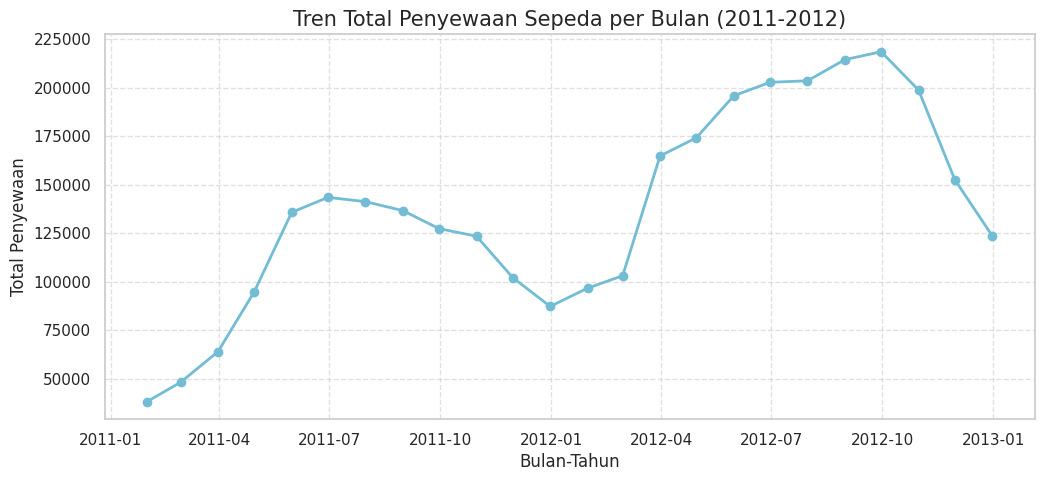

In [21]:
plt.figure(figsize=(12, 5))
plt.plot(
    monthly_rentals["dteday"],
    monthly_rentals["cnt"],
    marker='o',
    linewidth=2,
    color="#72BCD4"
)
plt.title("Tren Total Penyewaan Sepeda per Bulan (2011-2012)", fontsize=15) # Menambahkan info tahun
plt.xlabel("Bulan-Tahun")
plt.ylabel("Total Penyewaan")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Pertanyaan 2: Bagaimana pengaruh kondisi cuaca terhadap rata-rata jumlah penyewaan sepeda harian selama periode tahun 2011 hingga 2012?

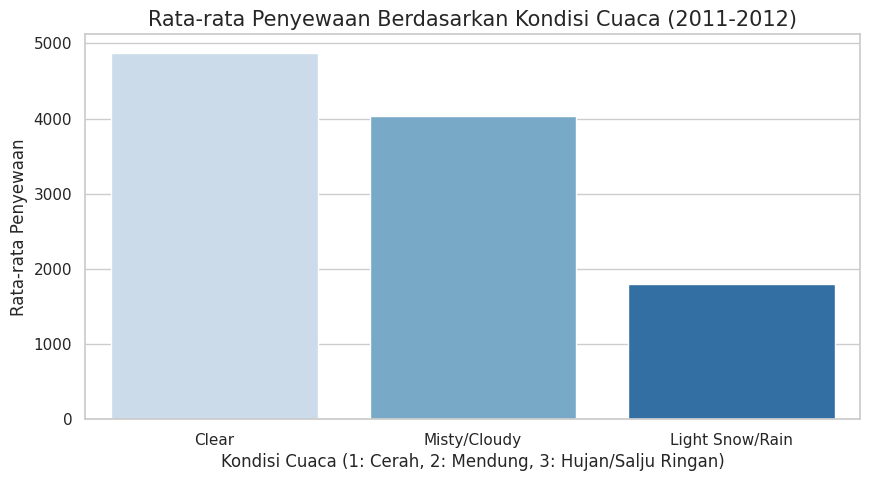

In [22]:
plt.figure(figsize=(10, 5))
sns.barplot(
    x="weathersit",
    y="cnt",
    data=weather_rentals,
    hue="weathersit",
    palette="Blues",
    legend=False
)
plt.title("Rata-rata Penyewaan Berdasarkan Kondisi Cuaca (2011-2012)", fontsize=15)
plt.xlabel("Kondisi Cuaca (1: Cerah, 2: Mendung, 3: Hujan/Salju Ringan)")
plt.ylabel("Rata-rata Penyewaan")
plt.show()

**Insight:** (Opsional)
- Analisis Tren Tahunan (2011-2012): Berdasarkan grafik garis, terlihat pertumbuhan total penyewaan sepeda yang sangat signifikan dari tahun 2011 ke 2012. Puncak penyewaan terjadi pada bulan-bulan di pertengahan hingga akhir tahun (musim panas dan gugur), yang menunjukkan adanya pola musiman yang kuat dalam cohort pengguna ini.  
- Dampak Kondisi Cuaca terhadap Mobilitas: Rata-rata penyewaan harian selama periode 2011-2012 menunjukkan bahwa cuaca cerah (Clear/Partly Cloudy) mendominasi total penggunaan. Terdapat penurunan jumlah penyewa yang sangat drastis ketika kondisi cuaca berubah menjadi Light Snow/Rain. Hal ini mengindikasikan bahwa kenyamanan cuaca merupakan faktor penentu utama bagi pengguna dalam memilih layanan berbagi sepeda ini.  
- Diferensiasi Pola Waktu (Working Day vs Holiday) di Tahun 2012: Di tahun 2012, ditemukan perbedaan karakteristik waktu puncak penyewaan yang sangat kontras. Pada hari kerja (workingday), penyewaan memuncak pada jam sibuk berangkat dan pulang kantor (pukul 08:00 dan 17:00), sedangkan pada hari libur, aktivitas penyewaan meningkat secara bertahap sejak siang hari hingga sore hari. Hal ini membuktikan bahwa pada hari kerja sepeda digunakan sebagai moda transportasi rutin, sementara pada hari libur lebih bersifat rekreasional.

## Analisis Lanjutan (Opsional)

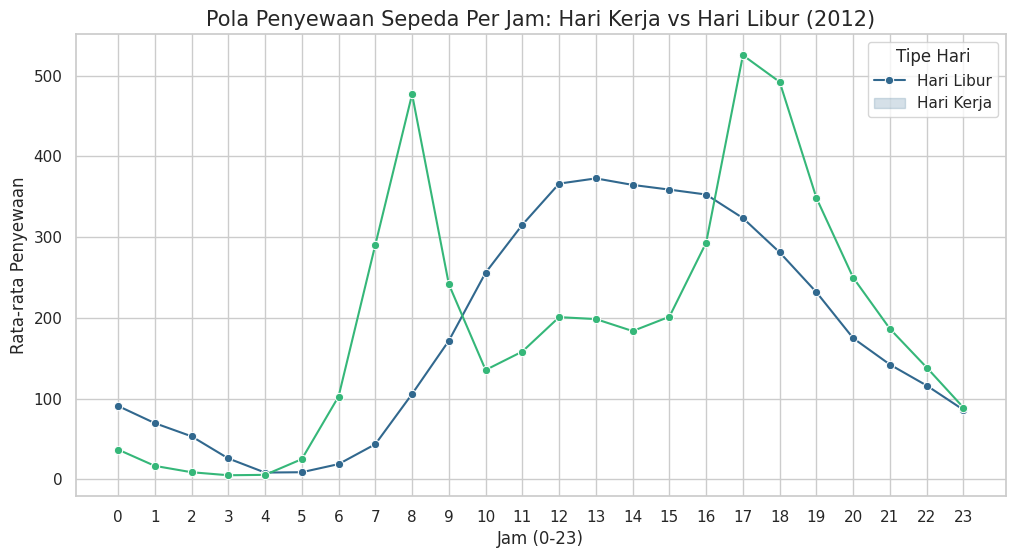

In [23]:
plt.figure(figsize=(12, 6))
sns.lineplot(
    x="hr",
    y="cnt",
    data=hourly_pattern,
    hue="workingday",
    palette="viridis",
    marker="o"
)
plt.title("Pola Penyewaan Sepeda Per Jam: Hari Kerja vs Hari Libur (2012)", fontsize=15)
plt.xlabel("Jam (0-23)")
plt.ylabel("Rata-rata Penyewaan")
plt.xticks(range(0, 24))
plt.legend(title="Tipe Hari", labels=["Hari Libur", "Hari Kerja"])
plt.show()

## Conclusion & Recommendation

- **Conclusion Pertanyaan 1:** Terjadi tren pertumbuhan jumlah penyewa sepeda yang sangat positif dari tahun 2011 ke 2012, dengan lonjakan total penyewaan yang signifikan di hampir setiap bulannya. Aktivitas penyewaan ini memiliki pola musiman yang jelas, di mana permintaan mencapai titik tertingginya pada bulan September 2012 (Musim Gugur/Fall) dan mencapai titik terendah pada awal tahun (Januari-Februari).
- **Conclusion Pertanyaan 2:** Kondisi lingkungan berupa cuaca memiliki korelasi kuat terhadap jumlah penyewa harian sepanjang periode 2011-2012. Rata-rata penyewaan harian tertinggi secara konsisten terjadi saat kondisi cuaca cerah (Clear/Partly Cloudy), sementara terjadi penurunan jumlah penyewa yang sangat drastis ketika kondisi cuaca berubah menjadi Light Snow/Rain. Hal ini menunjukkan bahwa kenyamanan cuaca adalah prioritas utama bagi cohort pengguna dalam memutuskan untuk menggunakan layanan ini.
- **Conclusion Pertanyaan 3 (Opsional):** Berdasarkan analisis pola waktu di tahun 2012, terdapat perbedaan jam sibuk (rush hour) yang signifikan berdasarkan tipe hari. Pada hari kerja (workingday), puncak penyewaan terjadi pada pukul 08:00 dan 17:00, yang mengindikasikan penggunaan sepeda untuk kebutuhan transportasi rutin. Sedangkan pada hari libur, pola penyewaan lebih merata dengan puncak aktivitas terjadi pada siang hingga sore hari (pukul 12:00-16:00) untuk kebutuhan rekreasi.

**Rekomendasi Action Item:**

- **Optimasi Armada & Ketersediaan:** Tim operasional harus memastikan jumlah unit sepeda tersedia maksimal pada jam-jam puncak harian (pukul 08:00 dan 17:00) serta melakukan manajemen stok ekstra pada bulan-bulan ramai seperti Mei hingga September.
- **Inovasi Layanan Berbasis Cuaca:** Mengingat penurunan drastis saat hujan/salju, tim dapat mempertimbangkan pemberian promo atau diskon khusus "Rainy Day" untuk menjaga minat pengguna casual agar tetap menggunakan layanan dalam kondisi cuaca yang kurang mendukung.
- **Penjadwalan Maintenance:** Melakukan perawatan unit secara besar-besaran sebaiknya dijadwalkan pada awal tahun (Januari-Februari) saat permintaan sedang berada di titik terendah. Hal ini bertujuan agar seluruh armada dalam kondisi prima saat memasuki musim puncak di pertengahan tahun.